# 🛒 Walmart Weekly Sales Prédiction par régression
**Projet Jedha Apprentissage automatique supervisé**

**Objectif :** Prédire les ventes hebdomadaires (`Weekly_Sales`) des magasins Walmart à partir de variables économiques et temporelles.

---
## Plan
- **Partie 1** : EDA + Prétraitement
- **Partie 2** : Régression linéaire (baseline)
- **Partie 3** : Régularisation (Ridge / Lasso)
- **Bonus** : GridSearchCV pour optimiser l'hyperparamètre

---
# PARTIE 1 EDA et Prétraitement

## 1.1 Imports

On importe toutes les bibliothèques dont on aura besoin :
- **pandas / numpy** : manipulation et calcul sur les données
- **matplotlib / seaborn** : visualisations
- **scikit-learn** : tout le pipeline ML (prétraitement, modèles, évaluation)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Affichage propre
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


## 1.2 Chargement du dataset

On charge le CSV Jedha. Si tu travailles sur **Google Colab**, deux options :
- Upload manuel via `files.upload()` (décommenter le bloc Colab ci-dessous)
- Ou mettre le fichier dans ton Google Drive et le monter

Si tu travailles en **local / VS Code**, il suffit de mettre le CSV dans le même dossier que le notebook.

In [4]:
# ---- OPTION A : Google Colab (upload manuel) ----
# from google.colab import files
# uploaded = files.upload()  # sélectionne Walmart_Store_sales.csv

# ---- OPTION B : local ou Colab avec chemin direct ----
df = pd.read_csv('/Walmart_Store_sales.csv')

print(f'Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes')
df.head(10)

Dimensions : 150 lignes x 8 colonnes


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092
5,4.0,28-05-2010,1857533.70,0.0,NaN,2.756,126.160226,7.896
6,15.0,03-06-2011,695396.19,0.0,69.80,4.069,134.855161,7.658
7,20.0,03-02-2012,2203523.20,0.0,39.93,3.617,213.023622,6.961
8,14.0,10-12-2010,2600519.26,0.0,30.54,3.109,NaN,NaN
9,3.0,NaN,418925.47,0.0,60.12,3.555,224.132020,6.833


## 1.3 Exploration initiale (EDA)

Avant tout nettoyage, on explore ce qu'on a :
- Les types de chaque colonne
- Les valeurs manquantes
- Les statistiques descriptives (min, max, moyenne, écart-type...)

In [5]:
# Types et valeurs non-nulles
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB


In [6]:
# Nombre et pourcentage de valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Valeurs manquantes': missing, 'Pourcentage (%)': missing_pct})

,Valeurs manquantes,Pourcentage (%)
Store,0,0.00
Date,18,12.00
Weekly_Sales,14,9.33
Holiday_Flag,12,8.00
Temperature,18,12.00
Fuel_Price,14,9.33
CPI,12,8.00
Unemployment,15,10.00


In [7]:
# Statistiques descriptives des colonnes numériques
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
mean,9.866667,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000
max,20.000000,2.771397e+06,1.000000,91.650000,4.193000,226.968844,14.313000


## 1.4 Visualisations

### Distribution de la variable cible
On commence par regarder comment se distribuent les ventes hebdomadaires.
Un histogramme permet de voir si la distribution est normale, asymétrique, s'il y a des valeurs extrêmes...

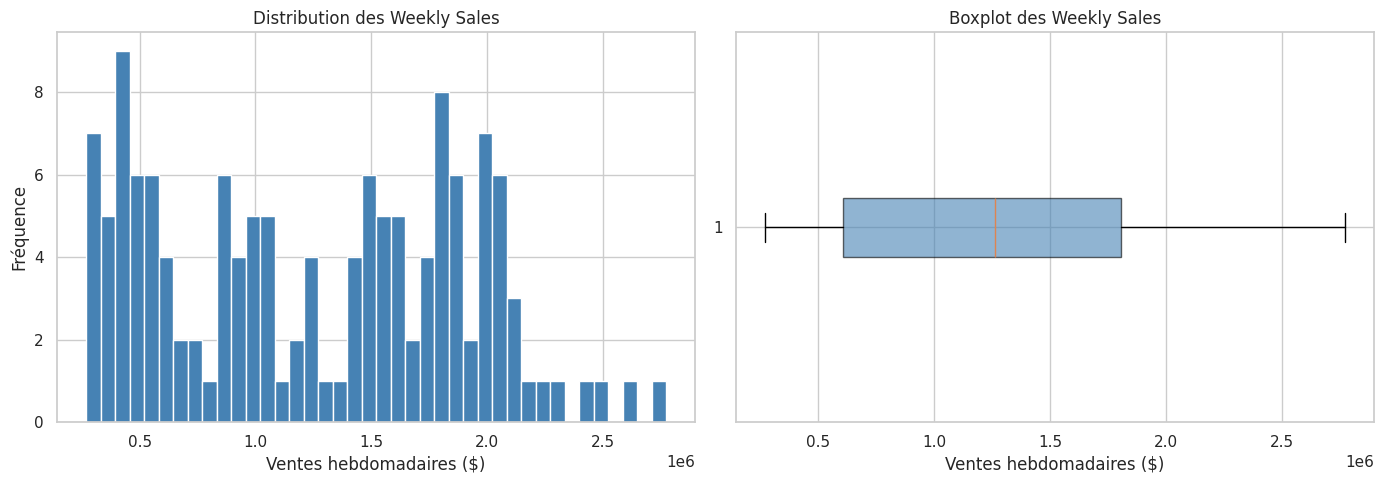

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['Weekly_Sales'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des Weekly Sales')
axes[0].set_xlabel('Ventes hebdomadaires ($)')
axes[0].set_ylabel('Fréquence')

# Boxplot pour visualiser les outliers
axes[1].boxplot(df['Weekly_Sales'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot des Weekly Sales')
axes[1].set_xlabel('Ventes hebdomadaires ($)')

plt.tight_layout()
plt.show()

### Corrélations entre variables numériques
La heatmap de corrélation permet de voir quelles variables sont liées à `Weekly_Sales`
et lesquelles sont corrélées entre elles (ce qui peut poser problème en régression).

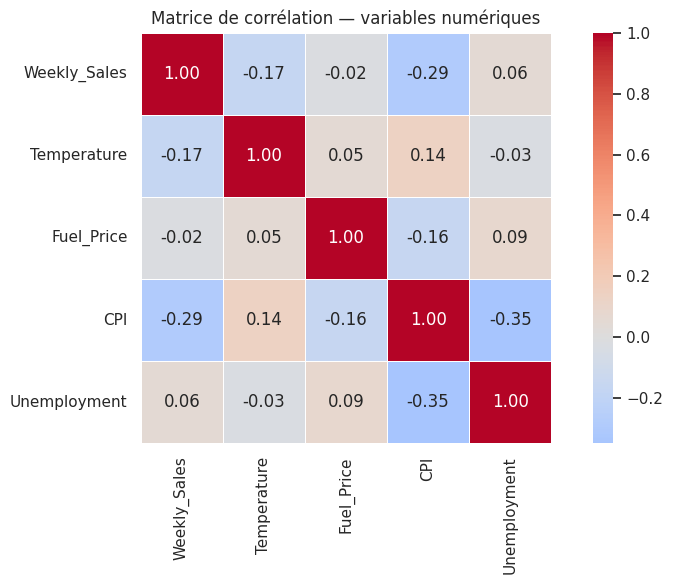

In [9]:
plt.figure(figsize=(9, 6))
corr = df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Matrice de corrélation — variables numériques')
plt.tight_layout()
plt.show()

### Ventes : semaines normales vs semaines de vacances
On compare la distribution des ventes selon que la semaine est fériée ou non.

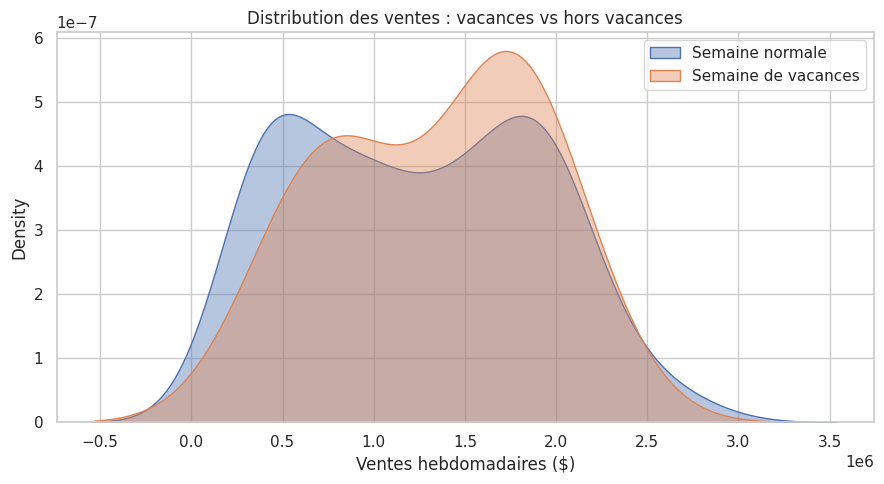

In [10]:
plt.figure(figsize=(9, 5))
data_holiday = df.dropna(subset=['Weekly_Sales', 'Holiday_Flag'])
labels = {0.0: 'Semaine normale', 1.0: 'Semaine de vacances'}

for flag, label in labels.items():
    subset = data_holiday[data_holiday['Holiday_Flag'] == flag]['Weekly_Sales']
    sns.kdeplot(subset, label=label, fill=True, alpha=0.4)

plt.title('Distribution des ventes : vacances vs hors vacances')
plt.xlabel('Ventes hebdomadaires ($)')
plt.legend()
plt.tight_layout()
plt.show()

### Ventes moyennes par magasin
Certains magasins sont beaucoup plus grands que d'autres, la variable `Store` est un facteur clé.

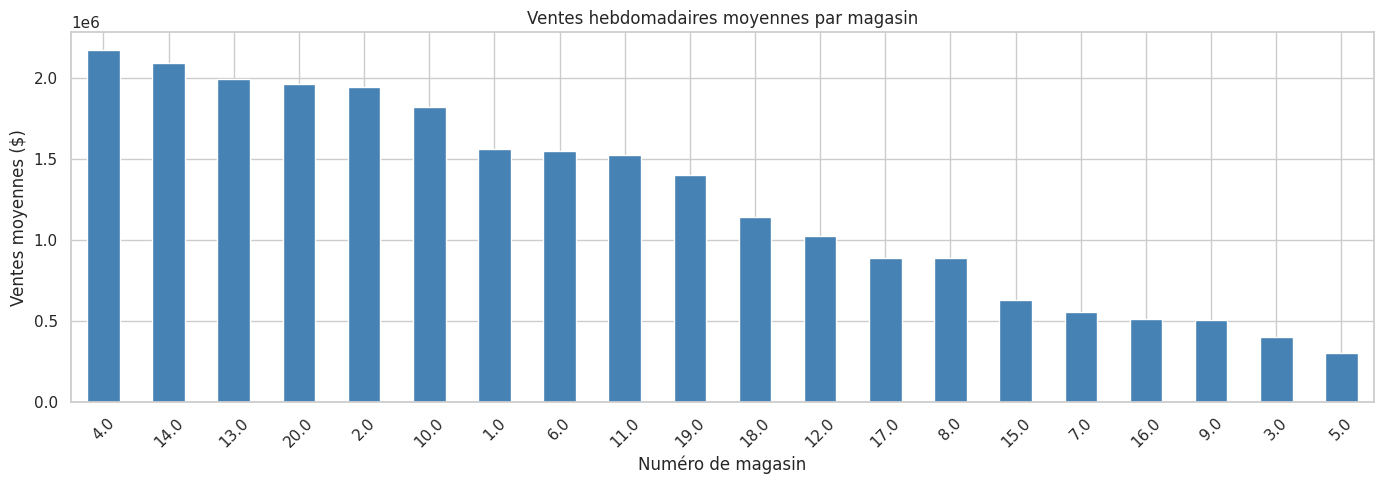

In [11]:
plt.figure(figsize=(14, 5))
store_means = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
store_means.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Ventes hebdomadaires moyennes par magasin')
plt.xlabel('Numéro de magasin')
plt.ylabel('Ventes moyennes ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 1.5 Nettoyage des données (pandas)

### Étape 1 : Supprimer les lignes où Weekly_Sales est manquant

> **Pourquoi ?**  
> `Weekly_Sales` est notre **variable cible (Y)**. On ne peut jamais imputer (estimer) les valeurs manquantes de la cible — ça introduirait un biais dans les prédictions. On supprime ces lignes, tout simplement.

In [12]:
print(f'Avant nettoyage : {df.shape[0]} lignes')

df = df.dropna(subset=['Weekly_Sales'])

print(f'Après suppression des NaN sur Weekly_Sales : {df.shape[0]} lignes')

Avant nettoyage : 150 lignes
Après suppression des NaN sur Weekly_Sales : 136 lignes


### Étape 2 : Feature engineering sur la colonne Date

> **Pourquoi ?**  
> Un modèle ML ne peut pas traiter une date brute comme `"18-02-2011"`. On la convertit en **4 variables numériques** : année, mois, jour, jour de la semaine.  
> Ces features capturent des patterns temporels (saisonnalité, fin d'année, weekends...).

In [13]:
# Conversion en datetime (format jour-mois-année)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# Extraction des composantes temporelles
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Day']        = df['Date'].dt.day
df['DayOfWeek']  = df['Date'].dt.dayofweek  # 0=lundi, 6=dimanche

# On supprime la colonne Date originale (inutilisable telle quelle en ML)
df = df.drop(columns=['Date'])

print('Features temporelles créées :')
print(df[['Year', 'Month', 'Day', 'DayOfWeek']].head(5))

Features temporelles créées :
     Year  Month   Day  DayOfWeek
0  2011.0    2.0  18.0        4.0
1  2011.0    3.0  25.0        4.0
3     NaN    NaN   NaN        NaN
4  2010.0    5.0  28.0        4.0
5  2010.0    5.0  28.0        4.0


### Étape 3 : Suppression des outliers (règle ±3σ)

> **Pourquoi ?**  
> Les valeurs aberrantes peuvent fortement biaiser un modèle de régression (surtout linéaire).  
> La règle standard : on considère comme outlier toute valeur qui s'éloigne de plus de **3 écarts-types** de la moyenne.  
> On applique ça sur : `Temperature`, `Fuel_Price`, `CPI`, `Unemployment` (comme indiqué par Jedha).

Formule : on garde uniquement les lignes où **X̄ - 3σ ≤ valeur ≤ X̄ + 3σ**

In [14]:
cols_outliers = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

print(f'Avant suppression outliers : {df.shape[0]} lignes')

for col in cols_outliers:
    mean = df[col].mean()
    std  = df[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    before = df.shape[0]
    # On garde les lignes dans l'intervalle OU les NaN (on les gérera dans le pipeline)
    df = df[(df[col].between(lower, upper)) | (df[col].isna())]
    print(f'  {col:15s} → [{lower:.2f}, {upper:.2f}] — {before - df.shape[0]} lignes supprimées')

df = df.reset_index(drop=True)
print(f'Après suppression outliers : {df.shape[0]} lignes')

Avant suppression outliers : 136 lignes
  Temperature     → [5.31, 116.40] — 0 lignes supprimées
  Fuel_Price      → [1.88, 4.76] — 0 lignes supprimées
  CPI             → [57.36, 298.82] — 0 lignes supprimées
  Unemployment    → [2.81, 12.52] — 5 lignes supprimées
Après suppression outliers : 131 lignes


---
## 1.6 Séparation X / Y et train/test split

> **X** = toutes les colonnes sauf `Weekly_Sales`  
> **Y** = `Weekly_Sales` (la cible à prédire)

On divise en 80% entraînement / 20% test avec `random_state=42` pour la reproductibilité.

In [15]:
X = df.drop(columns=['Weekly_Sales'])
y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train : {X_train.shape} | X_test : {X_test.shape}')
print(f'y_train : {y_train.shape} | y_test : {y_test.shape}')

X_train : (104, 10) | X_test : (27, 10)
y_train : (104,) | y_test : (27,)


## 1.7 Pipeline de prétraitement scikit-learn

Jedha distingue deux types de colonnes, traitées différemment :

| Type | Colonnes | Traitement |
|---|---|---|
| **Catégorielles** | `Store`, `Holiday_Flag` | `OneHotEncoder` → transforme en colonnes binaires (0/1) |
| **Numériques** | `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `Year`, `Month`, `Day`, `DayOfWeek` | `StandardScaler` → centre et réduit (moyenne=0, std=1) + impute les NaN |

> **Pourquoi scaler ?**  
> La régression linéaire est sensible aux différences d'échelle. Temperature (°F) et Unemployment (%) n'ont pas la même unité — sans scaling, les coefficients seraient incomparables.

> **Pourquoi un Pipeline ?**  
> Le Pipeline garantit qu'on applique le même prétraitement sur train ET test, sans fuite de données (data leakage). Le scaler est "appris" uniquement sur le train.

In [16]:
from sklearn.impute import SimpleImputer

# Définition des colonnes
cat_features = ['Store', 'Holiday_Flag']
num_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
                'Year', 'Month', 'Day', 'DayOfWeek']

# Pipeline pour les variables numériques : imputation des NaN + standardisation
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # remplace les NaN par la médiane
    ('scaler',  StandardScaler())
])

# Pipeline pour les variables catégorielles : imputation + encodage
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # remplace NaN par la valeur la plus fréquente
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Assemblage avec ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

print('Preprocessor défini')

Preprocessor défini


---
# PARTIE 2 Modèle baseline : Régression Linéaire

## 2.1 Entraînement du modèle

On assemble le préprocesseur + le modèle dans un seul Pipeline.

> **Pourquoi un seul Pipeline ?**  
> C'est la bonne pratique scikit-learn. `.fit()` fait tout en une étape : prétraitement sur train, puis entraînement du modèle. `.predict()` applique le prétraitement au test puis prédit.

In [17]:
# Pipeline complet : préprocesseur + modèle
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Entraînement
lr_pipeline.fit(X_train, y_train)

print('Modèle entraîné')

Modèle entraîné


## 2.2 Évaluation des performances

On évalue sur **les deux ensembles** (train et test) pour détecter d'éventuels problèmes :

| Métrique | Description |
|---|---|
| **RMSE** (Root Mean Squared Error) | Erreur moyenne en dollars — plus faible = mieux |
| **R²** (coefficient de détermination) | Part de variance expliquée — 1.0 = parfait, 0 = inutile |

> Si R² train >> R² test → **overfitting** → on devra régulariser (Partie 3)

In [18]:
# Prédictions
y_train_pred = lr_pipeline.predict(X_train)
y_test_pred  = lr_pipeline.predict(X_test)

# Métriques
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
r2_train   = r2_score(y_train, y_train_pred)
r2_test    = r2_score(y_test,  y_test_pred)

print('=== Régression Linéaire ===')
print(f'  RMSE Train : {rmse_train:,.0f} $')
print(f'  RMSE Test  : {rmse_test:,.0f} $')
print(f'  R²    Train : {r2_train:.4f}')
print(f'  R²    Test  : {r2_test:.4f}')

=== Régression Linéaire ===
  RMSE Train : 100,071 $
  RMSE Test  : 188,478 $
  R²    Train : 0.9777
  R²    Test  : 0.8977


### Valeurs prédites vs réelles

Un bon modèle doit aligner les points sur la diagonale y=x.  
Si les points s'éloignent beaucoup, le modèle a du mal à capturer la variance.

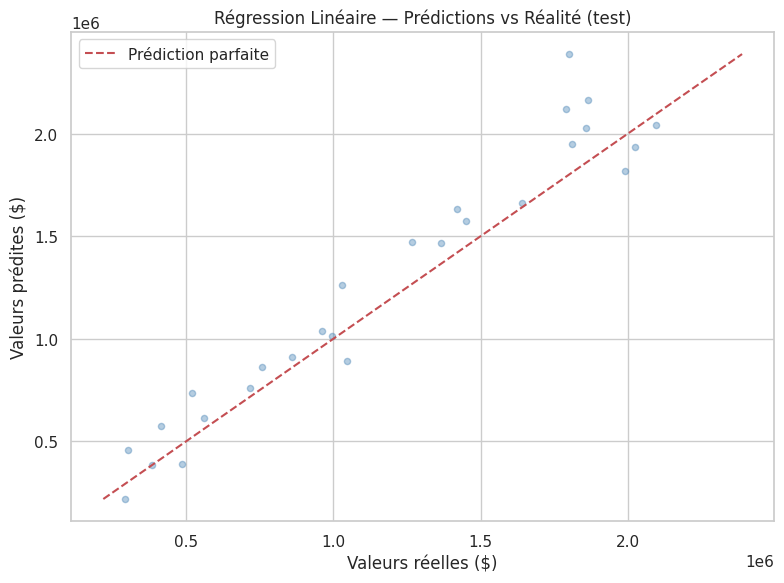

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.4, color='steelblue', s=20)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
plt.xlabel('Valeurs réelles ($)')
plt.ylabel('Valeurs prédites ($)')
plt.title('Régression Linéaire — Prédictions vs Réalité (test)')
plt.legend()
plt.tight_layout()
plt.show()

## 2.3 Analyse des coefficients

> **Pourquoi analyser les coefficients ?**  
> En régression linéaire, chaque coefficient indique l'impact d'une variable sur `Weekly_Sales` **si les autres sont constantes**.  
> - Un **coefficient positif élevé** → la variable fait monter les ventes
> - Un **coefficient négatif élevé** → la variable fait baisser les ventes
> - Un coefficient proche de 0 → variable peu influente

Comme on a standardisé les features numériques, les coefficients sont **comparables entre eux**.

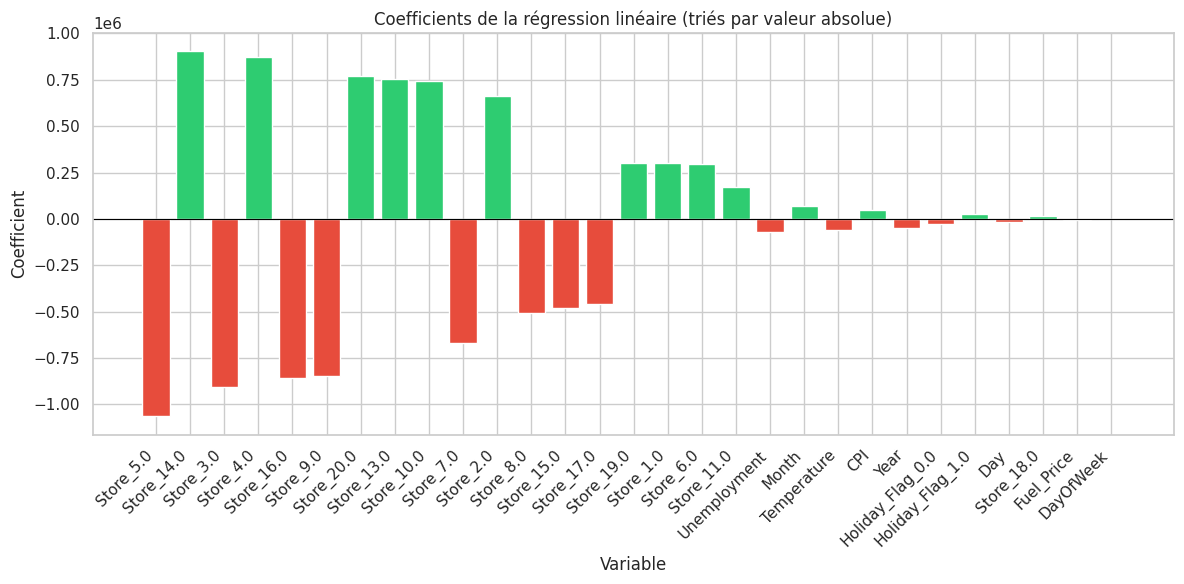


Top 10 variables les plus influentes :
   Feature   Coefficient
 Store_5.0 -1.063969e+06
Store_14.0  9.046220e+05
 Store_3.0 -9.039391e+05
 Store_4.0  8.745514e+05
Store_16.0 -8.556212e+05
 Store_9.0 -8.488401e+05
Store_20.0  7.695677e+05
Store_13.0  7.522959e+05
Store_10.0  7.413137e+05
 Store_7.0 -6.696862e+05


In [20]:
# Récupérer les noms de features après transformation
cat_encoder = lr_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feature_names

# Récupérer les coefficients
coefs = lr_pipeline.named_steps['model'].coef_
coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefs})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

# Visualisation
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.bar(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Coefficients de la régression linéaire (triés par valeur absolue)')
plt.xlabel('Variable')
plt.ylabel('Coefficient')
plt.tight_layout()
plt.show()

print('\nTop 10 variables les plus influentes :')
print(coef_df.head(10).to_string(index=False))

---
# PARTIE 3 Régularisation : Ridge et Lasso

## Rappel théorique : pourquoi régulariser ?

La régression linéaire classique minimise uniquement les erreurs de prédiction.  
En **régularisant**, on ajoute une pénalité sur la taille des coefficients :

| Modèle | Pénalité ajoutée | Effet |
|---|---|---|
| **Ridge** (L2) | somme des carrés des coefs | Réduit tous les coefs, aucun n'est mis à zéro |
| **Lasso** (L1) | somme des valeurs absolues des coefs | Peut mettre certains coefs **exactement à zéro** → sélection de variables |

L'hyperparamètre **alpha** contrôle la force de la pénalité :  
- alpha = 0 → équivalent à LinearRegression  
- alpha grand → forte régularisation, coefs très petits  

## 3.1 Ridge (régularisation L2)

In [23]:
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))  # alpha=1.0 par défaut
])

ridge_pipeline.fit(X_train, y_train)

# Évaluation
y_train_ridge = ridge_pipeline.predict(X_train)
y_test_ridge  = ridge_pipeline.predict(X_test)

print('=== Ridge (alpha=1.0) ===')
print(f'  RMSE Train : {np.sqrt(mean_squared_error(y_train, y_train_ridge)):,.0f} $')
print(f'  RMSE Test  : {np.sqrt(mean_squared_error(y_test,  y_test_ridge)):,.0f} $')
print(f'  R²    Train : {r2_score(y_train, y_train_ridge):.4f}')
print(f'  R²    Test  : {r2_score(y_test,  y_test_ridge):.4f}')

=== Ridge (alpha=1.0) ===
  RMSE Train : 149,384 $
  RMSE Test  : 216,126 $
  R²    Train : 0.9502
  R²    Test  : 0.8655


## 3.2 Lasso (régularisation L1)

In [24]:
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=1.0, max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)

# Évaluation
y_train_lasso = lasso_pipeline.predict(X_train)
y_test_lasso  = lasso_pipeline.predict(X_test)

print('=== Lasso (alpha=1.0) ===')
print(f'  RMSE Train : {np.sqrt(mean_squared_error(y_train, y_train_lasso)):,.0f} $')
print(f'  RMSE Test  : {np.sqrt(mean_squared_error(y_test,  y_test_lasso)):,.0f} $')
print(f'  R²    Train : {r2_score(y_train, y_train_lasso):.4f}')
print(f'  R²    Test  : {r2_score(y_test,  y_test_lasso):.4f}')

# Combien de coefs sont à zéro avec Lasso ?
lasso_coefs = lasso_pipeline.named_steps['model'].coef_
n_zeros = np.sum(lasso_coefs == 0)
print(f'\n  Coefficients mis à zéro par Lasso : {n_zeros} / {len(lasso_coefs)}')

=== Lasso (alpha=1.0) ===
  RMSE Train : 100,071 $
  RMSE Test  : 188,476 $
  R²    Train : 0.9777
  R²    Test  : 0.8977

  Coefficients mis à zéro par Lasso : 1 / 29


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.103e+10, tolerance: 4.662e+09
  model = cd_fast.enet_coordinate_descent(


## 3.3 Comparaison des 3 modèles

In [25]:
results = {
    'Modèle':      ['LinearRegression', 'Ridge (α=1)', 'Lasso (α=1)'],
    'RMSE Train':  [
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        np.sqrt(mean_squared_error(y_train, y_train_ridge)),
        np.sqrt(mean_squared_error(y_train, y_train_lasso))
    ],
    'RMSE Test':   [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_ridge)),
        np.sqrt(mean_squared_error(y_test, y_test_lasso))
    ],
    'R² Train':    [
        r2_score(y_train, y_train_pred),
        r2_score(y_train, y_train_ridge),
        r2_score(y_train, y_train_lasso)
    ],
    'R² Test':     [
        r2_score(y_test, y_test_pred),
        r2_score(y_test, y_test_ridge),
        r2_score(y_test, y_test_lasso)
    ]
}

results_df = pd.DataFrame(results)
results_df[['RMSE Train', 'RMSE Test']] = results_df[['RMSE Train', 'RMSE Test']].applymap(lambda x: f'{x:,.0f} $')
results_df[['R² Train', 'R² Test']] = results_df[['R² Train', 'R² Test']].applymap(lambda x: f'{x:.4f}')
print(results_df.to_string(index=False))

          Modèle RMSE Train RMSE Test R² Train R² Test
LinearRegression  100,071 $ 188,478 $   0.9777  0.8977
     Ridge (α=1)  149,384 $ 216,126 $   0.9502  0.8655
     Lasso (α=1)  100,071 $ 188,476 $   0.9777  0.8977


/tmp/ipykernel_48756/267986412.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_df[['RMSE Train', 'RMSE Test']] = results_df[['RMSE Train', 'RMSE Test']].applymap(lambda x: f'{x:,.0f} $')
/tmp/ipykernel_48756/267986412.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_df[['R² Train', 'R² Test']] = results_df[['R² Train', 'R² Test']].applymap(lambda x: f'{x:.4f}')


---
# BONUS GridSearchCV : optimisation de l'hyperparamètre alpha

> **Objectif :** Trouver automatiquement la meilleure valeur d'alpha pour Ridge (ou Lasso).  
> GridSearchCV teste plusieurs valeurs d'alpha par **validation croisée (cross-validation)** sur le train set,  
> et sélectionne celle qui minimise l'erreur en généralisation.

On teste des valeurs d'alpha sur une **échelle logarithmique** : de 0.01 à 10 000.

In [26]:
# Pipeline Ridge pour GridSearch
ridge_gs_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

# Grille de valeurs d'alpha à tester
param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 100, 500, 1000, 5000, 10000]
}

# GridSearchCV avec 5-fold cross-validation
# scoring='neg_root_mean_squared_error' : on minimise le RMSE (négatif car sklearn maximise)
grid_search = GridSearchCV(
    ridge_gs_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,  # utilise tous les cœurs disponibles
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\n Meilleur alpha trouvé : {grid_search.best_params_["model__alpha"]}')
print(f'   RMSE CV (train) : {-grid_search.best_score_:,.0f} $')

Fitting 5 folds for each of 9 candidates, totalling 45 fits

 Meilleur alpha trouvé : 0.01
   RMSE CV (train) : 142,383 $


In [27]:
# Évaluation du meilleur modèle sur le test set
best_model = grid_search.best_estimator_
y_test_best = best_model.predict(X_test)

print('=== Ridge — Meilleur alpha (GridSearchCV) ===')
print(f'  Alpha optimal : {grid_search.best_params_["model__alpha"]}')
print(f'  RMSE Test     : {np.sqrt(mean_squared_error(y_test, y_test_best)):,.0f} $')
print(f'  R²    Test    : {r2_score(y_test, y_test_best):.4f}')

=== Ridge — Meilleur alpha (GridSearchCV) ===
  Alpha optimal : 0.01
  RMSE Test     : 189,230 $
  R²    Test    : 0.8969


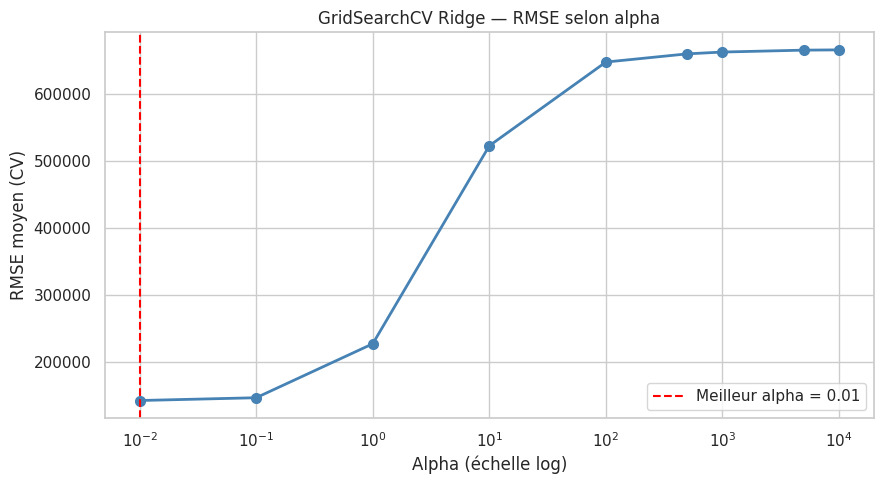

In [28]:
# Courbe RMSE en fonction d'alpha
cv_results = pd.DataFrame(grid_search.cv_results_)
alphas = cv_results['param_model__alpha'].astype(float)
rmse_cv = -cv_results['mean_test_score']

plt.figure(figsize=(9, 5))
plt.semilogx(alphas, rmse_cv, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.axvline(grid_search.best_params_['model__alpha'], color='red', linestyle='--',
            label=f'Meilleur alpha = {grid_search.best_params_["model__alpha"]}')
plt.xlabel('Alpha (échelle log)')
plt.ylabel('RMSE moyen (CV)')
plt.title('GridSearchCV Ridge — RMSE selon alpha')
plt.legend()
plt.tight_layout()
plt.show()

---
# Conclusion

Récapitulons ce qu'on a fait et ce qu'on a appris :

### Prétraitement
- Suppression des lignes sans `Weekly_Sales` (cible manquante → jamais d'imputation)
- Feature engineering sur `Date` → 4 variables numériques exploitables
- Suppression des outliers (règle ±3σ)
- Pipeline scikit-learn : OneHotEncoder sur Store/Holiday_Flag, StandardScaler sur numériques

### Modèles
- **Régression linéaire** : modèle baseline simple et interprétable
- **Ridge** : réduit tous les coefficients → bonne généralisation
- **Lasso** : met certains coefs à zéro → sélection automatique de variables
- **GridSearchCV** : optimisation automatique de l'hyperparamètre alpha

### Variables les plus importantes
Les coefficients de la régression linéaire révèlent quelles variables influencent le plus les ventes hebdomadaires (à analyser dans ton contexte).

### Limites
La régression linéaire suppose une relation **linéaire** entre les features et la cible.  
Pour améliorer davantage les prédictions, on pourrait explorer des modèles non-linéaires : Random Forest, Gradient Boosting...